basic data loading

In [ ]:
from datasets import load_dataset

ds = load_dataset(
    "imagefolder",
    data_dir=r"C:\Users\sandesh lavshetty\OneDrive\Desktop\clg\iiitn_1st_yr\6th_sem\competitions\miniproj\Potato_Tuber_Diseased_Caption_Dataset\Potato_Tuber_Diseased_Caption_Dataset\Images",
)

print(ds["train"][0])
# Expected output: {'image': <PIL.Image...>, 'caption': 'A cut potato tuber showing mild potato tuber greening disorder near the peel.'}

In [ ]:
# a sample
sample = ds["train"][0]
print(sample["caption"])          # the text
sample["image"]                   # PIL image you can display or transform

# dataset info
print(ds)
print(ds["train"].features)

2. splitting mthod


In [ ]:
from datasets import load_dataset

# 1. load everything first (ImageFolder returns a DatasetDict only if splits exist;
#    otherwise it puts everything in "train").  We'll create the splits ourselves.
raw_ds = load_dataset(
    "imagefolder",
    data_dir=r"C:\Users\sandesh lavshetty\OneDrive\Desktop\clg\iiitn_1st_yr\6th_sem\competitions\miniproj\Potato_Tuber_Diseased_Caption_Dataset\Potato_Tuber_Diseased_Caption_Dataset\Images",
)

# 2. split into train/val/test (80 % train, 10 % val, 10 % test)
splits = raw_ds["train"].train_test_split(test_size=0.2, seed=42)   # 80/20
val_test = splits["test"].train_test_split(test_size=0.5, seed=42)  # split the 20 into 10/10

ds = {
    "train": splits["train"],
    "validation": val_test["train"],
    "test": val_test["test"]
}

# quick check
print(ds["train"][0])
print("Train:", len(ds["train"]), "Val:", len(ds["validation"]), "Test:", len(ds["test"]))

Yes — the numbers you see (`Train: 1477`, `Val: 185`, `Test: 185`) are **image counts**, **not caption counts**.

ImageFolder collapses the five caption rows that refer to the same image into **one dataset example** (because they share the same `file_name`).  
So:

* 1 847 images ≈ 9 000 / 5  
* 80 % / 10 % / 10 % split → ~1 477 / 185 / 185

That is exactly what you want for an image-captioning task: one image → one training instance, even though you still have five human captions available per image if you need them (e.g. for evaluation metrics that average over multiple references).

In image-captioning papers / benchmarks you **always** keep a **validation** split:

* You need it for **early-stopping** / **checkpoint selection** while training.  
* BLEU, CIDEr, METEOR, SPICE scores are computed on validation after every epoch (and on the held-out test set only once at the very end).

Typical split ratios (followed by COCO, Flickr30k, etc.):

* 80 % train  
* 10 % validation (sometimes called “val” or “dev”)  
* 10 % test

So yes—create **train / validation / test** exactly as shown above.

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

# Load image
image = ds["train"][0]["image"]

# Display the image
plt.imshow(image)
plt.axis('off')  # Turn off axis for better visualization
plt.show()

Image fail test

In [ ]:
import os

img_dir = r"C:\Users\sandesh lavshetty\OneDrive\Desktop\clg\iiitn_1st_yr\6th_sem\competitions\miniproj\Potato_Tuber_Diseased_Caption_Dataset\Potato_Tuber_Diseased_Caption_Dataset\Images"

print(os.path.exists(os.path.join(img_dir, "1W2_71.jpg")))

Final set to save with fail image test case

In [ ]:
from datasets import load_dataset, Image
import os

ds = load_dataset(
    "imagefolder",
    data_dir=r"C:\Users\sandesh lavshetty\OneDrive\Desktop\clg\iiitn_1st_yr\6th_sem\competitions\miniproj\Potato_Tuber_Diseased_Caption_Dataset\Potato_Tuber_Diseased_Caption_Dataset\Images",
)

# Disable automatic PIL loading
ds = ds.cast_column("image", Image(decode=False))

image_root = r"C:\Users\sandesh lavshetty\OneDrive\Desktop\clg\iiitn_1st_yr\6th_sem\competitions\miniproj\Potato_Tuber_Diseased_Caption_Dataset\Potato_Tuber_Diseased_Caption_Dataset\Images"

def file_exists(example):
    return os.path.exists(os.path.join(image_root, example["image"]["path"]))

ds["train"] = ds["train"].filter(file_exists)

ds.save_to_disk("potato_tuber_dataset")

In [ ]:
missing_name = "1W2_71.jpg"

count = 0
for ex in ds["train"]:
    if ex["image"]["path"] == missing_name:
        count += 1

print(count)

In [1]:
from datasets import load_from_disk

ds = load_from_disk("potato_tuber_dataset")

train_ds = ds["train"]

print(len(train_ds))
print(train_ds[0])

1661
{'image': {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00H\x00H\x00\x00\xff\xe1\t\xa6Exif\x00\x00MM\x00*\x00\x00\x00\x08\x00\x16\x01\x00\x00\x03\x00\x00\x00\x01\x10\x00\x00\x00\x01\x01\x00\x03\x00\x00\x00\x01\t\x00\x00\x00\x01\x0e\x00\x02\x00\x00\x00\x01\x00\x00\x00\x00\x01\x0f\x00\x02\x00\x00\x00\x05\x00\x00\x02"\x01\x10\x00\x02\x00\x00\x00\t\x00\x00\x02(\x01\x12\x00\x03\x00\x00\x00\x01\x00\x01\x00\x00\x011\x00\x02\x00\x00\x00\x1c\x00\x00\x022\x012\x00\x02\x00\x00\x00\x14\x00\x00\x02N\x02\x13\x00\x03\x00\x00\x00\x01\x00\x02\x00\x00\x02 \x00\x04\x00\x00\x00\x01\x00\x00\x00\x00\x02!\x00\x04\x00\x00\x00\x01\x00\x00\x00\x00\x02"\x00\x04\x00\x00\x00\x01\x00\x00\x00\x00\x02#\x00\x04\x00\x00\x00\x01\x00\x00\x00\x00\x02$\x00\x04\x00\x00\x00\x01\x00\x00\x00\x00\x87i\x00\x04\x00\x00\x00\x01\x00\x00\x02b\x88%\x00\x04\x00\x00\x00\x01\x00\x00\x05\x92\x880\x00\x03\x00\x00\x00\x01\x00\x00\x00\x00\x882\x00\x04\x00\x00\x00\x01\x00\x00\x00\x00\x9c\x9b\x00\x01\x00\x00\x00\x02\x00\x00\x

In [2]:
from PIL import Image
import matplotlib.pyplot as plt

for i in range(5):   # print first 5 samples
    sample = train_ds[i]

    image = sample["image"]
    captions = sample["captions"]

    plt.imshow(image)
    plt.axis("off")
    plt.show()

    print("Captions:")
    for j, cap in enumerate(captions):
        print(f"{j+1}. {cap}")

    print("-"*50)

KeyError: 'captions'

In [ ]:
import os

image_folder = r"C:\Users\sandesh lavshetty\OneDrive\Desktop\clg\iiitn_1st_yr\6th_sem\competitions\miniproj\Potato_Tuber_Diseased_Caption_Dataset\Potato_Tuber_Diseased_Caption_Dataset\Images"

missing = []

for ex in ds["train"]:
    fname = ex["image"]["path"]
    full_path = os.path.join(image_folder, fname)

    if not os.path.exists(full_path):
        missing.append(full_path)

print("Missing files:", len(missing))
print(missing[:20])

Final with fail test image with train,test,val

In [3]:
from datasets import load_dataset, Image, DatasetDict
import os

# -----------------------------
# Paths
# -----------------------------
dataset_root = r"C:\Users\sandesh lavshetty\OneDrive\Desktop\clg\iiitn_1st_yr\6th_sem\competitions\miniproj\Potato_Tuber_Diseased_Caption_Dataset\Potato_Tuber_Diseased_Caption_Dataset\Images"

save_path = r"C:\Users\sandesh lavshetty\OneDrive\Desktop\clg\iiitn_1st_yr\6th_sem\competitions\miniproj\potato_tuber_dataset"

# -----------------------------
# Load dataset
# -----------------------------
ds = load_dataset(
    "imagefolder",
    data_dir=dataset_root
)

# Disable automatic decoding
ds = ds.cast_column("image", Image(decode=False))

# -----------------------------
# Remove broken images
# -----------------------------
def file_exists(example):
    return os.path.exists(example["image"]["path"])

ds["train"] = ds["train"].filter(file_exists)

print("Dataset size after cleaning:", len(ds["train"]))

# -----------------------------
# Train / Validation / Test Split
# -----------------------------

split1 = ds["train"].train_test_split(test_size=0.1, seed=42)

train_ds = split1["train"]
temp_ds = split1["test"]

split2 = temp_ds.train_test_split(test_size=0.5, seed=42)

val_ds = split2["train"]
test_ds = split2["test"]

final_ds = DatasetDict({
    "train": train_ds,
    "validation": val_ds,
    "test": test_ds
})

print(final_ds)

# -----------------------------
# Save dataset
# -----------------------------
final_ds.save_to_disk(save_path)

print("Dataset saved to:", save_path)

Resolving data files:   0%|          | 0/1867 [00:00<?, ?it/s]

Dataset size after cleaning: 9230
DatasetDict({
    train: Dataset({
        features: ['image', 'caption'],
        num_rows: 8307
    })
    validation: Dataset({
        features: ['image', 'caption'],
        num_rows: 461
    })
    test: Dataset({
        features: ['image', 'caption'],
        num_rows: 462
    })
})


Saving the dataset (0/11 shards):   0%|          | 0/8307 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/461 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/462 [00:00<?, ? examples/s]

Dataset saved to: C:\Users\sandesh lavshetty\OneDrive\Desktop\clg\iiitn_1st_yr\6th_sem\competitions\miniproj\potato_tuber_dataset


In [1]:
from datasets import load_from_disk

dataset = load_from_disk(
    r"C:\Users\sandesh lavshetty\OneDrive\Desktop\clg\iiitn_1st_yr\6th_sem\competitions\miniproj\potato_tuber_dataset"
)
dataset = dataset.cast_column("image", Image(decode=True))
train_ds = dataset["train"]
val_ds = dataset["validation"]
test_ds = dataset["test"]

print(len(train_ds), len(val_ds), len(test_ds))
print(train_ds[0])

NameError: name 'Image' is not defined

In [8]:
print(train_ds[1])

{'image': <PIL.Image.Image image mode=RGB size=1410x2492 at 0x1F8230BD9A0>, 'caption': 'A cut-section of a potato tuber showing moderate dry rot within the internal tissue.'}


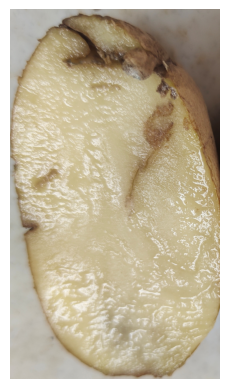

In [9]:
from PIL import Image
import matplotlib.pyplot as plt

# Load image
image = train_ds[1]["image"]

# Display the image
plt.imshow(image)
plt.axis('off')  # Turn off axis for better visualization
plt.show()

In [8]:
%pip install huggingface_hub datasets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
%pip install python-dotenv

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from huggingface_hub import login
from dotenv import load_dotenv

load_dotenv()
login(token=os.getenv("HF_TOKEN"))

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [5]:
final_ds.push_to_hub(
    "Sandesh-Lav/potato-tuber-caption-dataset",
    commit_message="Added 9000 cleaned dataset with train/validation/test splits and image captions"
)

Uploading the dataset shards:   0%|          | 0/11 [00:00<?, ? shards/s]

Map:   0%|          | 0/756 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/8 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

...

Map:   0%|          | 0/462 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/5 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/datasets/Sandesh-Lav/potato-tuber-caption-dataset/commit/355acd44b074930dba730f7295d9ee8e5e2a1758', commit_message='Added 9000 cleaned dataset with train/validation/test splits and image captions', commit_description='', oid='355acd44b074930dba730f7295d9ee8e5e2a1758', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/Sandesh-Lav/potato-tuber-caption-dataset', endpoint='https://huggingface.co', repo_type='dataset', repo_id='Sandesh-Lav/potato-tuber-caption-dataset'), pr_revision=None, pr_num=None)

In [1]:
from datasets import load_dataset

dataset = load_dataset("Sandesh-Lav/potato-tuber-caption-dataset")

image = dataset["train"][0]["image"]
caption = dataset["train"][0]["caption"]

print(caption)
image.show()

data/train-00000-of-00003.parquet:   0%|          | 0.00/366M [00:00<?, ?B/s]

c:\Users\sandesh lavshetty\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\sandesh lavshetty\.cache\huggingface\hub\datasets--Sandesh-Lav--potato-tuber-caption-dataset. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


data/train-00001-of-00003.parquet:   0%|          | 0.00/360M [00:00<?, ?B/s]

data/train-00002-of-00003.parquet:   0%|          | 0.00/358M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/56.6M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/1661 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/92 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/93 [00:00<?, ? examples/s]

A whole potato tuber showing severe external manifestation of bacterial soft rot with extensive tissue degradation.


AttributeError: 'dict' object has no attribute 'show'

In [4]:
from datasets import load_dataset

dataset = load_dataset(
    "Sandesh-Lav/potato-tuber-caption-dataset",
    download_mode="reuse_dataset_if_exists"
)

In [6]:
from datasets import load_dataset
from datasets import Image

dataset = load_dataset("Sandesh-Lav/potato-tuber-caption-dataset")

# decode images
dataset = dataset.cast_column("image", Image())

image = dataset["train"][0]["image"]
caption = dataset["train"][0]["caption"]

print(caption)
image.show()

A whole potato tuber showing severe external manifestation of bacterial soft rot with extensive tissue degradation.


Conversions


In [ ]:
%pip install datasets torch torchvision tensorflow

1. PyTorch DataLoader + transforms

In [ ]:
import torch
from torchvision import transforms
from torch.utils.data import DataLoader
from datasets import load_dataset

# 1. load the HF dataset we just created
ds = load_dataset(
    "imagefolder",
    data_dir=r"C:\Users\sandesh lavshetty\OneDrive\Desktop\clg\iiitn_1st_yr\6th_sem\competitions\miniproj\Potato_Tuber_Diseased_Caption_Dataset\Potato_Tuber_Diseased_Caption_Dataset",
    split="train"
)

# 2. define transforms
train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),                     # PIL -> [0,1]
    transforms.Normalize(                     # ImageNet stats (change if needed)
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])
])

def transform_batch(batch):
    """Apply transforms to a HF batch (dict of lists)."""
    batch["pixel_values"] = [
        train_tfms(img.convert("RGB")) for img in batch["image"]
    ]
    # keep captions if you need them later
    batch["labels"] = batch["caption"]
    return batch

# 3. set format -> torch tensors
ds.set_transform(transform_batch)

# 4. wrap in DataLoader
dataloader = DataLoader(
    ds.with_format("torch"),
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

# 5. iterate
for batch in dataloader:
    images = batch["pixel_values"]   # shape (B, 3, 224, 224)
    captions = batch["labels"]         # list[str]
    # … training step here …

2. TensorFlow tf.data.Dataset

In [ ]:
import tensorflow as tf
from datasets import load_dataset

ds = load_dataset(
    "imagefolder",
    data_dir=r"C:\Users\sandesh lavshetty\OneDrive\Desktop\clg\iiitn_1st_yr\6th_sem\competitions\miniproj\Potato_Tuber_Diseased_Caption_Dataset\Potato_Tuber_Diseased_Caption_Dataset",
    split="train"
)

IMG_SIZE = 224
BATCH = 8

def parse_tf(img, caption):
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.image.random_flip_left_right(img)
    img = tf.cast(img, tf.float32) / 255.0
    # optional per-channel normalization
    img = tf.image.per_image_standardization(img)
    return img, caption

def gen():
    for sample in ds:
        img = tf.keras.utils.img_to_array(sample["image"])
        yield img, sample["caption"]

tf_ds = (
    tf.data.Dataset.from_generator(
        gen,
        output_signature=(
            tf.TensorSpec(shape=(None, None, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(), dtype=tf.string)
        )
    )
    .map(parse_tf, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(512)
    .batch(BATCH)
    .prefetch(tf.data.AUTOTUNE)
)

# usage
for images, captions in tf_ds.take(1):
    print(images.shape)   # (8, 224, 224, 3)